# Noble (1962) Purkinje-fibre model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from scipy.integrate import solve_ivp

plt.rcParams['lines.color'] = 'k'

In [2]:
# Noble (1962) Purkinje-fibre model parameters.
# Units:
#   time: ms
#   voltage: mV
#   current density: microA / cm^2
#   conductance density: mmho / cm^2
#   capacitance: microF / cm^2

params = namedtuple(
    "params",
    [
        "C",
        "g_Na_max",
        "g_Na_background",
        "g_K2_max",
        "g_Kadd",
        "E_Na",
        "E_K",
        "g_An",
        "E_An",
        "I_app",
    ],
)

In [3]:
def _x_over_expm1(x):
    """Stable evaluation of x / (exp(x) - 1), including x = 0."""
    x = np.asarray(x)
    small = np.abs(x) < 1e-7
    result = np.empty_like(x, dtype=float)
    result[small] = 1.0 - x[small] / 2.0 + x[small] ** 2 / 12.0
    result[~small] = x[~small] / np.expm1(x[~small])
    return float(result) if result.ndim == 0 else result

def steady_state_gates(E_m):
    """Return m_inf, h_inf, and n_inf at a specified membrane potential."""
    alpha_n = 0.001 * _x_over_expm1((-E_m - 50.0) / 10.0)
    beta_n = 0.002 * np.exp((-E_m - 90.0) / 80.0)

    alpha_h = 0.17 * np.exp((-E_m - 90.0) / 20.0)
    beta_h = 1.0 / (np.exp((-E_m - 42.0) / 10.0) + 1.0)

    alpha_m = 1.5 * _x_over_expm1((-E_m - 48.0) / 15.0)
    beta_m = 0.6 * _x_over_expm1((E_m + 8.0) / 5.0)

    m_inf = alpha_m / (alpha_m + beta_m)
    h_inf = alpha_h / (alpha_h + beta_h)
    n_inf = alpha_n / (alpha_n + beta_n)

    return m_inf, h_inf, n_inf

def get_currents_from_solution(solution, model_parameters):
    """Returns ion current values, given the state solution (E_m, m, h, n)."""
    E_m, m, h, n = solution.y

    g_Na_max = model_parameters.g_Na_max
    g_Na_background = model_parameters.g_Na_background
    g_K2_max = model_parameters.g_K2_max
    g_Kadd = model_parameters.g_Kadd


    E_Na = model_parameters.E_Na
    E_K = model_parameters.E_K

    g_An = model_parameters.g_An
    E_An = model_parameters.E_An

    # Instantaneous and delayed potassium conductances: equations (5)-(6)
    g_K1 = (
        1.2 * np.exp((-E_m - 90) / 50)
        + 0.015 * np.exp((E_m + 90) / 60)
    )
    g_K2 = g_K2_max * n**4

    I_Na = (g_Na_max * m**3 * h + g_Na_background) * (E_m - E_Na)
    I_K = (g_K1 + g_K2) * (E_m - E_K)
    I_An = g_An * (E_m - E_An)

    return I_Na, I_K, I_An

def noble_1962_model(t, state, model_parameters):
    """
    Noble (1962) Purkinje-fibre membrane model, equations (1)-(20).

    Parameters
    ----------
    t : float
        Time in ms.

    state : tuple with 4 elements
        Current values of:
            E_m : membrane potential in mV
            m   : sodium activation gate
            h   : sodium inactivation gate
            n   : delayed potassium activation gate

    model_parameters : collections.namedtuple
        Model parameters stored as attributes.

    Returns
    -------
    tuple with 4 elements
        dE_m/dt, dm/dt, dh/dt, dn/dt.
    """

    C = model_parameters.C

    g_Na_max = model_parameters.g_Na_max
    g_Na_background = model_parameters.g_Na_background
    g_K2_max = model_parameters.g_K2_max
    g_Kadd = model_parameters.g_Kadd

    E_Na = model_parameters.E_Na
    E_K = model_parameters.E_K

    g_An = model_parameters.g_An
    E_An = model_parameters.E_An

    I_app = model_parameters.I_app

    E_m = state[0]
    m = state[1]
    h = state[2]
    n = state[3]

    # Potassium rate constants: equations (8)-(9)
    alpha_n = 0.001 * _x_over_expm1((-E_m - 50.0) / 10.0)
    beta_n = 0.002 * np.exp((-E_m - 90.0) / 80.0)

    # Sodium h-gate rate constants: equations (16)-(17)
    alpha_h = 0.17 * np.exp((-E_m - 90.0) / 20.0)
    beta_h = 1.0 / (np.exp((-E_m - 42.0) / 10.0) + 1.0)

    # Sodium m-gate rate constants: equations (18)-(19)
    alpha_m = 1.5 * _x_over_expm1((-E_m - 48.0) / 15.0)
    beta_m = 0.6 * _x_over_expm1((E_m + 8.0) / 5.0)

    # Instantaneous and delayed potassium conductances: equations (5)-(6)
    g_K1 = (
        1.2 * np.exp((-E_m - 90) / 50)
        + 0.015 * np.exp((E_m + 90) / 60)
    )
    g_K2 = g_K2_max * n**4

    # Ionic currents: equations (3), (10), and (20)
    I_Na = (g_Na_max * m**3 * h + g_Na_background) * (E_m - E_Na)
    I_K = (g_K1 + g_K2 + g_Kadd) * (E_m - E_K)
    I_An = g_An * (E_m - E_An)

    # Membrane equation (4), using outward-positive current convention.
    dE_m_dt = (I_app - I_Na - I_K - I_An) / C

    # Gating equations (7), (13), and (14)
    dm_dt = alpha_m * (1.0 - m) - beta_m * m
    dh_dt = alpha_h * (1.0 - h) - beta_h * h
    dn_dt = alpha_n * (1.0 - n) - beta_n * n

    return (dE_m_dt, dm_dt, dh_dt, dn_dt)

## Spontaneous rhythm (Figure 8A)

In [4]:
# No anion current, so g_An = 0.
model_parameters = params(
    C=12.0, # 12 x higher than in squid axon!
    g_Na_max=400.0,
    g_Na_background=0.14,
    g_K2_max=1.2,
    g_Kadd=0, # No "additional K conductance"
    E_Na=40.0,
    E_K=-100.0,
    g_An=0.0,
    E_An=-60.0,   # irrelevant while g_An = 0
    I_app=0.0,
)

In [5]:
E_m0 = -80.0
m0, h0, n_inf0 = steady_state_gates(E_m0)

# Noble states that the initial n value was guessed and loses influence after
# one cycle. A value of 0.30 gives rapid convergence to the stable rhythm.
initial_state = (E_m0, m0, h0, 0.30)

In [6]:
# First, integrate long enough to remove dependence on the guessed initial n.
burn_in = solve_ivp(
    fun=noble_1962_model,
    t_span=(0.0, 1400.0),
    y0=initial_state,
    args=(model_parameters,),
    method="RK45",
)

if not burn_in.success:
    raise RuntimeError(burn_in.message)


In [7]:
# Reproduce approximately two cycles, matching the 0-2 s extent of Fig. 8
plot_duration = 2000.0
t_eval = np.arange(0.0, plot_duration + 0.1, 0.1)

solution = solve_ivp(
    fun=noble_1962_model,
    t_span=(0.0, plot_duration),
    y0=burn_in.y[:, -1],
    t_eval=t_eval,
    args=(model_parameters,),
    method="RK45"
)

In [8]:
# Compute Ion currents from the state variables
ina, ik, ian = get_currents_from_solution(solution, model_parameters)

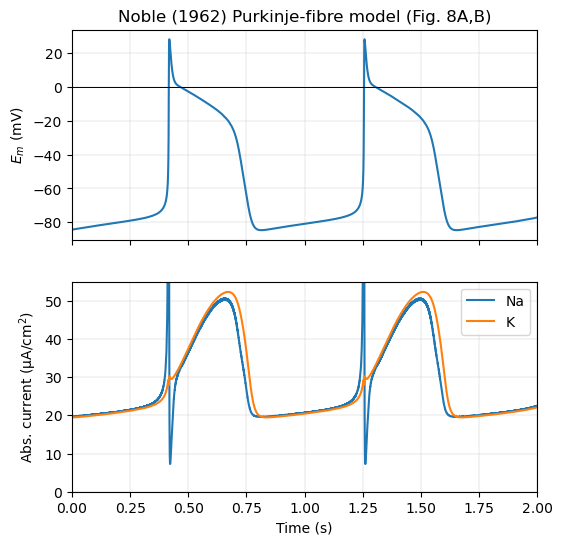

In [9]:
fig, (ax,ax1) = plt.subplots(2,1,figsize=(6,6), sharex=True)
ax.plot(solution.t / 1000.0, solution.y[0], linewidth=1.5)
ax.axhline(0.0, linewidth=0.7)
ax.set_xlim(0.0, plot_duration/1e3)
# ax.set_ylim(-100.0, 50.0)
ax.set_ylabel(r"$E_m$ (mV)")
ax.set_title("Noble (1962) Purkinje-fibre model (Fig. 8A,B)")

ax1.plot(solution.t/ 1000.0, ina*(-1), label='Na')
ax1.plot(solution.t/ 1000.0, ik, label='K')
ax1.legend()
ax1.set_ylim(0, 55)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel('Abs. current (µA/cm$^2$)')

for axi in (ax,ax1):
    axi.grid(lw=0.2)

## Action potential freuqency in Purkinje fibres depends on membrane permeability. Vary the conductance of anions $g_{An}$ to illustrate this (Fig. 14)

In [10]:
# No anion current, so g_An = 0.
base_params = params(
    C=12.0, # 12 x higher than in squid axon!
    g_Na_max=400.0,
    g_Na_background=0.14,
    g_K2_max=1.2,
    g_Kadd=0, # No "additional K conductance"
    E_Na=40.0,
    E_K=-100.0,
    g_An=0.0,
    E_An=-60.0,   # irrelevant while g_An = 0
    I_app=0.0,
)

g_Ans = [0, 0.075, 0.18, 0.4] # mmho/cm2

In [11]:
E_m0 = -80.0
m0, h0, n_inf0 = steady_state_gates(E_m0)

# Noble states that the initial n value was guessed and loses influence after
# one cycle. A value of 0.30 gives rapid convergence to the stable rhythm.
initial_state = (E_m0, m0, h0, 0.30)

In [12]:
Em_trajectories = []

for g_An in g_Ans:
    p = base_params._replace(g_An = g_An)

    # First, integrate long enough to remove dependence on the guessed initial n.
    burn_in = solve_ivp(
        fun=noble_1962_model,
        t_span=(0.0, 1400.0),
        y0=initial_state,
        args=(p,),
        method="RK45",
    )
    
    # Reproduce approximately two cycles, matching the 0-2 s extent of Fig. 8
    solution = solve_ivp(
        fun=noble_1962_model,
        t_span=(0.0, plot_duration),
        y0=burn_in.y[:, -1],
        t_eval=t_eval,
        args=(p,),
        method="RK45"
    )

    Em_trajectories.append(solution.y[0])
Em_trajectories = np.array(Em_trajectories)

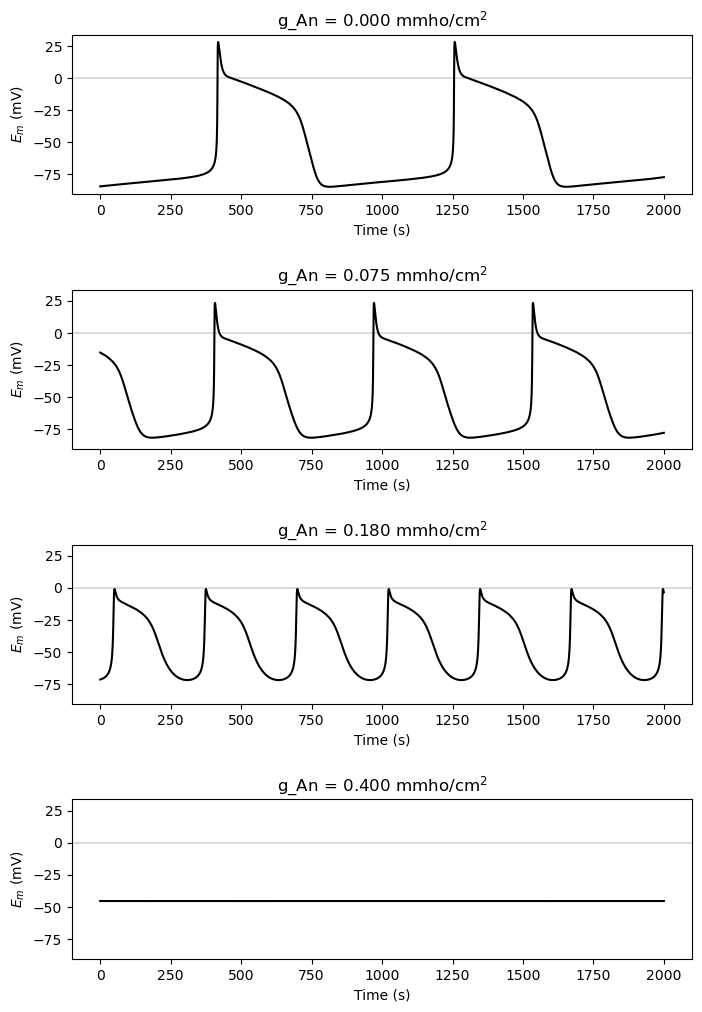

In [13]:
f, axs = plt.subplots(len(g_Ans), 1, sharey=True, figsize=(8,12))
plt.subplots_adjust(hspace=0.6)

for g_An, em, ax in zip(g_Ans, Em_trajectories, axs):
    ax.plot(t_eval, em, 'k')
    ax.axhline(lw=0.2)
    ax.set(title=f"g_An = {g_An:.3f} mmho/cm$^2$", 
          xlabel='Time (s)',
          ylabel='$E_m$ (mV)')